In [1]:
import os
import shutil
import re
import glob
import h5py as h5
import toml
import numpy as np
import matplotlib.pyplot as plt

from gwpy.segments import DataQualityFlag
from gwpy.segments import Segment
from gwpy.segments import SegmentList
from gwpy.timeseries import TimeSeries
from gwpy.frequencyseries import FrequencySeries

import bilby
from bilby.core.prior.analytical import Uniform, Cosine, Sine, PowerLaw, Gamma, Logistic
from bilby.gw.source import sinegaussian
from bilby.gw.source import lal_binary_black_hole
from bilby.gw.conversion import bilby_to_lalsimulation_spins
from bilby.gw.detector import InterferometerList
from bilby.core.utils.series import infft

import lal
from pycbc.waveform import get_sgburst_waveform
from pycbc.waveform import get_td_waveform
from pycbc.types.timeseries import TimeSeries as pycbcts
from pycbc.detector import Detector
from pycbc.filter import matched_filter

%matplotlib inline

: 

## Check science segments

In [2]:
hdq_files = f"/home/chiajui.chou/GW-anomaly-detection/makedata/H1-O3a:DCS-ANALYSIS_READY_C01:1.hdf5"
ldq_files = f"/home/chiajui.chou/GW-anomaly-detection/makedata/L1-O3a:DCS-ANALYSIS_READY_C01:1.hdf5"
hldq_files = f"/home/chiajui.chou/GW-anomaly-detection/makedata/H1L1-O3a:DCS-ANALYSIS_READY_C01:1.hdf5"
hdq = DataQualityFlag.read(hdq_files)
ldq = DataQualityFlag.read(ldq_files)
hldq = DataQualityFlag.read(hldq_files)

# hdq.plot().show()
# ldq.plot().show()
# hldq.plot().show()

In [3]:
O3a_start, O3a_end = 1238166018, 1253977218
O3b_start, O3b_end = 1256655618, 1269363618
last_omicron_seg_H1_start, last_omicron_seg_H1_end = 1238834630, 1238834630+21869
last_omicron_seg_L1_start, last_omicron_seg_L1_end = 1238771446, 1238771446+1463
last_HL_end = min(last_omicron_seg_H1_end, last_omicron_seg_L1_end)

def filter_seg(
        segmentlist,
        filter_end=None,
):
    output_list = SegmentList()
    for seg in segmentlist:
        if seg.end <= filter_end:
            output_list.append(seg)
        else:
            break

    return output_list 

# hseglist = filter_seg(hdq.active, last_omicron_seg_H1_end)
# lseglist = filter_seg(ldq.active, last_omicron_seg_L1_end)
# hlseglist = filter_seg(hldq.active, last_HL_end)

# hseglist.write("/home/chiajui.chou/GW-anomaly-detection/makedata/hseglist.segwizard", format="segwizard")
# lseglist.write("/home/chiajui.chou/GW-anomaly-detection/makedata/lseglist.segwizard", format="segwizard")
# hlseglist.write("/home/chiajui.chou/GW-anomaly-detection/makedata/hlseglist.segwizard", format="segwizard")

hseglist = SegmentList.read('/home/chiajui.chou/GW-anomaly-detection/makedata/hseglist.segwizard', format='segwizard')
lseglist = SegmentList.read('/home/chiajui.chou/GW-anomaly-detection/makedata/lseglist.segwizard', format='segwizard')
hlseglist = SegmentList.read('/home/chiajui.chou/GW-anomaly-detection/makedata/hlseglist.segwizard', format='segwizard')

print(f'H1 segs: {len(hseglist)}')
print(f'L1 segs: {len(lseglist)}')
print(f'H1L1 segs: {len(hlseglist)}')

H1 segs: 37
L1 segs: 39
H1L1 segs: 52


In [4]:
# [1238166018, 1238170289]

H1_id, L1_id = 23, 20
print(f"H1: {hseglist[H1_id]}, duration: {hseglist[H1_id].end - hseglist[H1_id].start}s.")
print(f"L1: {lseglist[L1_id]}, duration: {lseglist[L1_id].end - lseglist[L1_id].start}s.")

H1: [1238561172 ... 1238619975), duration: 58803s.
L1: [1238362764 ... 1238426681), duration: 63917s.


## Estimate ASD

In [7]:
ifos = ["H1", "L1"]
channels = {
    "H1": "H1:DCS-CALIB_STRAIN_CLEAN_SUB60HZ_C01",
    "L1": "L1:DCS-CALIB_STRAIN_CLEAN_SUB60HZ_C01",
}
sample_rate = 16384
fftlength = 8
asd_max_length = 3600

In [8]:
def get_source(ifo, start, end):
    folder_prefix = f'/ceph/mirror/frames/O3/hoft_C01_clean_sub60Hz/{ifo}/{ifo[0]}-{ifo}_HOFT_CLEAN_SUB60HZ_C01'
    label0 = int(start/1e5)
    labels = [label0]
    if end >= (label0+1)*1e5:
        labels.append(label0+1)

    gwf_folders = [f'{folder_prefix}-{label}' for label in labels] 
    source = []
    for gwf_folder in gwf_folders:
        source.extend(glob.glob(f'{gwf_folder}/*.gwf'))

    source = sorted(source)
    return source

def get_asd(
        ifo,
        source,
        asd_start,
        asd_end,
        fftlength=8,
        sample_rate=16384,
    ):
    ts = TimeSeries.read(
        source=source,
        channel=channels[ifo],
        start=asd_start,
        end=asd_end,
        gap='ignore',
    )
    ts = ts.resample(sample_rate)
    asd = ts.asd(
        fftlength=fftlength,
        overlap=fftlength/2,
        window='hann',
        method='median',
    )
    return asd

def get_asd_time(segmentlist):
    output_list = SegmentList()
    for seg in segmentlist:
        seg_start, seg_end = seg.start.gpsSeconds, seg.end.gpsSeconds
        seg_length = seg_end - seg_start
        if seg_length <= asd_max_length:
           output_list.append(Segment(seg_start, seg_end))
        else:
            st_list = [seg_start]
            st_list.extend([seg_start + asd_max_length*(n+1) for n in range(int(seg_length/asd_max_length))])
            ed_list = st_list[1:]
            ed_list.append(seg_end)
            for st, ed in zip(st_list, ed_list):
                output_list.append(Segment(st, ed))

    return output_list


In [9]:
ifo = 'H1'
# seglist = hseglist[36:37]
seglist = lseglist[38:39]

asd_folder = f"/home/chiajui.chou/GW-anomaly-detection/data/asds/{ifo}/O3"
asd_times = get_asd_time(seglist)
for seg in asd_times:
   asd_start, asd_end = seg.start, seg.end
   asd_length = asd_end - asd_start
   print(asd_start, asd_length)
#    source = get_source(ifo, asd_start, asd_end)
#    asd = get_asd(
#       ifo=ifo,
#       source=source,
#       asd_start=asd_start,
#       asd_end=asd_end,
#       fftlength=fftlength,
#       sample_rate=sample_rate,
#    )
#    asd.write(f"{asd_folder}/{ifo}_asd-{asd_start}-{asd_length}.txt")


1238771446 1463


## Glitches

### Fliter the glitch infos

In [10]:
H1_id, L1_id = 23, 20
print(f"H1: {hseglist[H1_id]}, duration: {hseglist[H1_id].end - hseglist[H1_id].start}s.")
print(f"L1: {lseglist[L1_id]}, duration: {lseglist[L1_id].end - lseglist[L1_id].start}s.")

H1: [1238561172 ... 1238619975), duration: 58803s.
L1: [1238362764 ... 1238426681), duration: 63917s.


In [11]:
ifos = ["H1", "L1"]
t_start = dict.fromkeys(ifos)
t_end = dict.fromkeys(ifos)
# t_start['H1'], t_end['H1'] = O3a_start, last_omicron_seg_H1_end
# t_start['L1'], t_end['L1'] = O3a_start, last_omicron_seg_L1_end
t_start['H1'], t_end['H1'] = 1238561172, 1238619975
t_start['L1'], t_end['L1'] = 1238362764, 1238426681

triginfos = dict.fromkeys(ifos)
for ifo in ifos:
    info_files = [
        # f'/home/chiajui.chou/GW-anomaly-detection/GWAK_setup/{ifo}_trigger_info-0.hdf5',
        # f'/home/chiajui.chou/GW-anomaly-detection/makedata/{ifo}_glitch_info.hdf5',
        f'/home/chiajui.chou/GW-anomaly-detection/makedata/blind-test/{ifo}_glitch_info.hdf5'
    ]

    info_list = []
    for info_file in info_files:
        with h5.File(info_file, 'r') as f:
            key = list(f.keys())[0]
            for info in f[key]:
                if (info['time'] >= t_start[ifo]) and (info['time'] < t_end[ifo]):
                    info_list.append(info)

    triginfos[ifo] = info_list

print(f"Number of H1 glitches:{len(triginfos['H1'])}")
print(f"Number of L1 glitches:{len(triginfos['L1'])}")

# for ifo in ifos:
#     glitch_info_file = f"/home/chiajui.chou/GW-anomaly-detection/makedata/blind-test/{ifo}_glitch_info.hdf5"
#     names = list(triginfos[ifo][0].dtype.names)
#     dt = np.dtype({'names': names, 'formats': ['f8']*(len(names) - 1) + [h5.string_dtype(encoding='ascii')]})
#     with h5.File(glitch_info_file, 'w') as w:
#         data = np.stack(triginfos[ifo])
#         w.create_dataset(
#             'glitch_info',
#             shape=data.shape,
#             dtype=dt,
#             data=data,
#         )

Number of H1 glitches:6581
Number of L1 glitches:7984


In [12]:
h5_file = "/home/chiajui.chou/GW-anomaly-detection/makedata/blind-test/L1_glitch_info.hdf5"
id = 0
with h5.File(h5_file, 'r') as f:
    print(f.keys())
    print(f['glitch_info'].dtype)
    print(f['glitch_info'][id])

<KeysViewHDF5 ['glitch_info']>
[('time', '<f8'), ('frequency', '<f8'), ('tstart', '<f8'), ('tend', '<f8'), ('fstart', '<f8'), ('fend', '<f8'), ('snr', '<f8'), ('q', '<f8'), ('amplitude', '<f8'), ('phase', '<f8'), ('trigger_file', 'O')]
(1.23836277e+09, 259.2351742, 1.23836277e+09, 1.23836277e+09, 257.48602131, 260.99620943, 5.1871732, 76.23440485, 1.71834278e-23, 0.16252045, b'/home/chiajui.chou/GW-anomaly-detection/GWAK_setup/L1/1238362764-63917/trigger_output/merge/L1:DCS-CALIB_STRAIN_CLEAN_SUB60HZ_C01/L1-DCS_CALIB_STRAIN_CLEAN_SUB60HZ_C01_OMICRON-1238362766-37260.h5')


### Select triggers from a target segment

In [12]:
target_segments = {'H1':hseglist[23:24], 'L1':lseglist[20:21]}
# selected_triggers = dict.fromkeys(ifos)
# for ifo in ifos:
#     print(f"{ifo}: {target_segments[ifo]}")
#     trigger_list = []
#     for info in triginfos[ifo]:
#         for seg in target_segments[ifo]:
#             st_check = info['time'] >= seg.start
#             ed_check = info['time'] <= seg.end
#             if st_check and ed_check:
#                 trigger_list.append(info['time'])

#     selected_triggers[ifo] = trigger_list
#     # print(selected_triggers[ifo])

# selected_triggers_file = '/home/chiajui.chou/GW-anomaly-detection/makedata/blind-test/selected_triggers.hdf5'
# with h5.File(selected_triggers_file, 'w') as w:
#     for ifo in ifos:
#         data = np.array(selected_triggers[ifo])
#         w.create_dataset(
#             f'{ifo}_triggers',
#             data=data
#         )

### Read glitch times and corresponding asd

In [13]:
def get_source(ifo, start, end):
    folder_prefix = f'/ceph/mirror/frames/O3/hoft_C01_clean_sub60Hz/{ifo}/{ifo[0]}-{ifo}_HOFT_CLEAN_SUB60HZ_C01'
    label0 = int(start/1e5)
    labels = [label0]
    if end >= (label0+1)*1e5:
        labels.append(label0+1)

    gwf_folders = [f'{folder_prefix}-{label}' for label in labels] 
    source = []
    for gwf_folder in gwf_folders:
        source.extend(glob.glob(f'{gwf_folder}/*.gwf'))

    source = sorted(source)
    return source

def select_asd(trigtime, asd_list):
    asd_times = [(int(file.split('/')[-1].split('-')[1]), int(file.split('/')[-1].split('-')[-1].split('.')[0])) for file in asd_list]
    for i in range(len(asd_times)):
        asd_sted = [asd_times[i][0], asd_times[i][0] + asd_times[i][1]]
        if (trigtime >= asd_sted[0]) and (trigtime < asd_sted[1]):
            asd = FrequencySeries.read(asd_list[i])
            # selected_asd_sted = asd_sted

    # return selected_asd_sted, asd
    return asd

def get_glitch_ts(ifo, trigtime, window_length=8):
    glitch_start, glitch_end = trigtime - window_length/2, trigtime + window_length/2
    source = get_source(ifo, glitch_start, glitch_end)
    ts = TimeSeries.read(
        source=source,
        channel=channels[ifo],
        start=glitch_start,
        end=glitch_end,
        gap='ignore',
    )
    return ts

def get_bg_ts(ifo, t0, window_length=8):
    bg_start, bg_end = t0, t0 + window_length
    source = get_source(ifo, bg_start, bg_end)
    ts = TimeSeries.read(
        source=source,
        channel=channels[ifo],
        start=bg_start,
        end=bg_end,
        gap='ignore',
    )
    return ts

def process(
        ts,
        asd,
        flow=30,
        fhigh=1500,
        resample=4096,
        crop_length=1,
 ):
    ts = ts.whiten(asd=asd)
    ts = ts.bandpass(flow, fhigh)
    ts = ts.crop(ts.t0.value + crop_length, ts.t0.value + ts.duration.value - crop_length)
    ts = ts.resample(resample)
    return ts

In [14]:
ifos = ["H1", "L1"]
asd_list = dict.fromkeys(ifos)
bgsegs = dict.fromkeys(ifos)
triggers = dict.fromkeys(ifos)
for ifo in ifos[:]:
    # ASD list
    asd_folder = f"/home/chiajui.chou/GW-anomaly-detection/data/asds/{ifo}/O3"
    asd_list[ifo] = glob.glob(f"{asd_folder}/*.txt")
    asd_list[ifo] = sorted(asd_list[ifo])

    # Get trigger times
    glitch_info = f'/home/chiajui.chou/GW-anomaly-detection/makedata/blind-test/{ifo}_glitch_info.hdf5'
    with h5.File(glitch_info, 'r') as f:
        # print(f.keys())
        triggers[ifo] = f[f'glitch_info']['time'][:]
        # print(triggers[ifo].shape)
        # print(select_asd(f[f'{ifo}_triggers'][0], asd_list[ifo]))

    # Get background segments
    bgseg_list = SegmentList()
    for seg in target_segments[ifo]:
        select_trig_times = []
        for trigtime in triggers[ifo]:
            if (trigtime >= seg.start) and (trigtime <= seg.end):
                select_trig_times.append(trigtime)

        if len(select_trig_times) != 0:
            if (select_trig_times[0] - 2 - seg.start) >= 8:
                new_seg = Segment(target_segments[ifo][0].start, select_trig_times[0] - 2)
                bgseg_list.append(new_seg)

            for i in range(len(select_trig_times) - 1):
                trig_distance = select_trig_times[i+1] - select_trig_times[i]
                if trig_distance >= (8+4):
                    new_seg = Segment(select_trig_times[i] + 2, select_trig_times[i+1] - 2)
                    bgseg_list.append(new_seg)

            if (seg.end - select_trig_times[-1] - 2) >= 8:
                new_seg = Segment(select_trig_times[-1] + 2, seg.end)
                bgseg_list.append(new_seg)

    bgsegs[ifo] = bgseg_list
    bgsegs[ifo].write(f'/home/chiajui.chou/GW-anomaly-detection/makedata/blind-test/{ifo}_bgseglist_selected.segwizard', format='segwizard')

    bgsegs[ifo] = SegmentList.read(f'/home/chiajui.chou/GW-anomaly-detection/makedata/blind-test/{ifo}_bgseglist_selected.segwizard', format='segwizard')

for ifo in ifos:
    print(f"{ifo} glitch number: {len(triggers[ifo])}")
    print(f"{ifo} background segments: {len(bgsegs[ifo])}")

H1 glitch number: 6581
H1 background segments: 1629
L1 glitch number: 7984
L1 background segments: 1764


### Generating Background t0s.

In [18]:
dset_n = 5
ifos = ['H1', 'L1']
wavs = ['bg', 'bbh', 'lfsg', 'hfsg', 'ccsn']
# wav = wavs[3]
for wav in wavs[:]:
    nsample = 6000
    bgseg_t_list = dict.fromkeys(ifos)
    if wav == 'bg':
        file_number = 1
    else:
        file_number = 4
    for i in range(0,file_number):
        for ifo in ifos:
            bgseg_t_list_fname = f'/home/chiajui.chou/GW-anomaly-detection/makedata/blind-test/{ifo}_bgseg_{wav}_6k{dset_n}_{i}.hdf5'
            nbg = len(bgsegs[ifo])
            print(f"{ifo}: {nbg} background segments.")

            # Generate random background noise segment id
            bgids = np.random.randint(0, nbg, nsample)

            # Randomly sample the start time of the background noise timeseries
            bgseg_t_list = []
            for id in bgids:
                ts_length = 8
                sample_st, sample_ed = bgsegs[ifo][id].start, bgsegs[ifo][id].end - ts_length
                bgsamplet0 = np.random.uniform(sample_st, sample_ed)
                bgseg_t_list.append(bgsamplet0)

            # Save the bgseg_t_list to a hdf5 file
            with h5.File(bgseg_t_list_fname, 'w') as w:
                data = np.array(bgseg_t_list)
                w.create_dataset(
                    'bgseg_t_list',
                    shape=data.shape,
                    dtype='f8',
                    data=data
                )

            # Check the bgseg_t_list
            with h5.File(bgseg_t_list_fname, 'r') as f:
                print(f"Number of time in t_list {bgseg_t_list_fname}, {ifo}: {len(f['bgseg_t_list'])}")

H1: 1629 background segments.
Number of time in t_list /home/chiajui.chou/GW-anomaly-detection/makedata/blind-test/H1_bgseg_bg_6k5_0.hdf5, H1: 6000
L1: 1764 background segments.
Number of time in t_list /home/chiajui.chou/GW-anomaly-detection/makedata/blind-test/L1_bgseg_bg_6k5_0.hdf5, L1: 6000
H1: 1629 background segments.
Number of time in t_list /home/chiajui.chou/GW-anomaly-detection/makedata/blind-test/H1_bgseg_bbh_6k5_0.hdf5, H1: 6000
L1: 1764 background segments.
Number of time in t_list /home/chiajui.chou/GW-anomaly-detection/makedata/blind-test/L1_bgseg_bbh_6k5_0.hdf5, L1: 6000
H1: 1629 background segments.
Number of time in t_list /home/chiajui.chou/GW-anomaly-detection/makedata/blind-test/H1_bgseg_bbh_6k5_1.hdf5, H1: 6000
L1: 1764 background segments.
Number of time in t_list /home/chiajui.chou/GW-anomaly-detection/makedata/blind-test/L1_bgseg_bbh_6k5_1.hdf5, L1: 6000
H1: 1629 background segments.
Number of time in t_list /home/chiajui.chou/GW-anomaly-detection/makedata/blin

In [32]:
ifos = ['H1', 'L1']
wav = "bg"
file_n = 4
for ifo in ifos:
    files = [f'/home/chiajui.chou/GW-anomaly-detection/makedata/blind-test/{ifo}_bgseg_{wav}_6k{i}.hdf5' for i in range(file_n)]
    for file in files:
        with h5.File(file, 'r') as f:
            print(file)
            # print(f.keys())
            print(f['bgseg_t_list'].shape)
            # print(f['bgseg_t_list'][:3])

/home/chiajui.chou/GW-anomaly-detection/makedata/blind-test/H1_bgseg_ccsn_5k0.hdf5
(1000,)
/home/chiajui.chou/GW-anomaly-detection/makedata/blind-test/H1_bgseg_ccsn_5k1.hdf5
(1000,)
/home/chiajui.chou/GW-anomaly-detection/makedata/blind-test/H1_bgseg_ccsn_5k2.hdf5
(1000,)
/home/chiajui.chou/GW-anomaly-detection/makedata/blind-test/H1_bgseg_ccsn_5k3.hdf5
(1000,)
/home/chiajui.chou/GW-anomaly-detection/makedata/blind-test/L1_bgseg_ccsn_5k0.hdf5
(1000,)
/home/chiajui.chou/GW-anomaly-detection/makedata/blind-test/L1_bgseg_ccsn_5k1.hdf5
(1000,)
/home/chiajui.chou/GW-anomaly-detection/makedata/blind-test/L1_bgseg_ccsn_5k2.hdf5
(1000,)
/home/chiajui.chou/GW-anomaly-detection/makedata/blind-test/L1_bgseg_ccsn_5k3.hdf5
(1000,)


### Load glitch time and find corresponding asd file

In [39]:
ifos = ["H1", "L1"]
channels = {
    "H1": "H1:DCS-CALIB_STRAIN_CLEAN_SUB60HZ_C01",
    "L1": "L1:DCS-CALIB_STRAIN_CLEAN_SUB60HZ_C01",
}
sample_rate = 16384
flow, fhigh = 30, 1500

t_start = dict.fromkeys(ifos)
t_end = dict.fromkeys(ifos)
t_start['H1'], t_end['H1'] = O3a_start, last_omicron_seg_H1_end
t_start['L1'], t_end['L1'] = O3a_start, last_omicron_seg_L1_end
trigtime_list = dict.fromkeys(ifos)
trigsnr_list = dict.fromkeys(ifos)
trigq_list = dict.fromkeys(ifos)
trigf_list = dict.fromkeys(ifos)
asd_list = dict.fromkeys(ifos)

for ifo in ifos:
    glitch_info_file = f"/home/chiajui.chou/GW-anomaly-detection/makedata/{ifo}_glitch_info.hdf5"
    with h5.File(glitch_info_file, 'r') as f:
        trigtime_list[ifo] = list(f['glitch_info']['time'])
        trigsnr_list[ifo] = list(f['glitch_info']['snr'])
        trigq_list[ifo] = list(f['glitch_info']['q'])
        trigf_list[ifo] = list(f['glitch_info']['frequency'])

    asd_folder = f"/home/chiajui.chou/GW-anomaly-detection/data/asds/{ifo}/O3"
    asd_list[ifo] = glob.glob(f"{asd_folder}/*.txt")
    asd_list[ifo] = sorted(asd_list[ifo])

for ifo in ifos:
    print(f"{ifo} glitch number: {len(trigtime_list[ifo])}")

H1 glitch number: 53250
L1 glitch number: 60653


In [40]:
def get_source(ifo, start, end):
    folder_prefix = f'/ceph/mirror/frames/O3/hoft_C01_clean_sub60Hz/{ifo}/{ifo[0]}-{ifo}_HOFT_CLEAN_SUB60HZ_C01'
    label0 = int(start/1e5)
    labels = [label0]
    if end >= (label0+1)*1e5:
        labels.append(label0+1)

    gwf_folders = [f'{folder_prefix}-{label}' for label in labels] 
    source = []
    for gwf_folder in gwf_folders:
        source.extend(glob.glob(f'{gwf_folder}/*.gwf'))

    source = sorted(source)
    return source

def select_asd(trigtime, asd_list):
    asd_times = [(int(file.split('/')[-1].split('-')[1]), int(file.split('/')[-1].split('-')[-1].split('.')[0])) for file in asd_list]
    for i in range(len(asd_times)):
        asd_sted = [asd_times[i][0], asd_times[i][0] + asd_times[i][1]]
        if (trigtime >= asd_sted[0]) and (trigtime < asd_sted[1]):
            asd = FrequencySeries.read(asd_list[i])
            # selected_asd_sted = asd_sted

    # return selected_asd_sted, asd
    return asd

def get_glitch_ts(ifo, trigtime, window_length=8):
    glitch_start, glitch_end = trigtime - window_length/2, trigtime + window_length/2
    source = get_source(ifo, glitch_start, glitch_end)
    ts = TimeSeries.read(
        source=source,
        channel=channels[ifo],
        start=glitch_start,
        end=glitch_end,
        gap='ignore',
    )
    return ts

def process(
        ts,
        asd,
        flow=30,
        fhigh=1500,
        resample=4096,
        crop_length=1,
 ):
    ts = ts.whiten(asd=asd)
    ts = ts.bandpass(flow, fhigh)
    ts = ts.crop(ts.t0.value + crop_length, ts.t0.value + ts.duration.value - crop_length)
    ts = ts.resample(resample)
    return ts


In [41]:
ifo = 'L1'
idstart, idend = 0, 5
t_list = trigtime_list[ifo][idstart:idend]
snr_list = trigsnr_list[ifo][idstart:idend]
q_list = trigq_list[ifo][idstart:idend]
f_list = trigf_list[ifo][idstart:idend]

pts_list = []
for trigtime in t_list:
    try:
        ts = get_glitch_ts(ifo, trigtime)
    except Exception as e:
        print(f"{trigtime}")
        print(str(e))

    asd = select_asd(trigtime, asd_list[ifo])
    pts = process(ts, asd)
    pts_list.append(pts.to_value())

glitch_data_file = f"/home/chiajui.chou/GW-anomaly-detection/data/glitch_ts/{ifo}/O3/{ifo}_O3_glitch-test.hdf5"
# with h5.File(glitch_data_file, 'w') as w:
#     data = np.stack(pts_list)
#     w.create_dataset(
#         'glitch',
#         shape=data.shape,
#         dtype='f8',
#         data=data,
#     )

#     names = ['time', 'snr', 'q', 'frequency']
#     dt = np.dtype({'names': names, 'formats': ['f8']*len(names)})
#     dlist = [(time, snr, q, frequency) for time, snr, q, frequency in zip(t_list, snr_list, q_list, f_list)]
#     data = np.array(dlist, dt)
#     w.create_dataset(
#         'glitch_info',
#         data=data
#     )

In [272]:
ifo = 'H1'
# ifo = 'L1'
id = 1

output_h5 = f"/home/chiajui.chou/GW-anomaly-detection/data/glitch_ts/{ifo}/O3/{ifo}_O3_glitch-0-10.hdf5"
with h5.File(output_h5, 'r') as f:
    print(f.keys())
    print(f['glitch'].shape)
    print(f['glitch'][id])
    print(f['glitch_info'].shape)
    print(f['glitch_info'][id].dtype.names)
    print(f['glitch_info'][id])

<KeysViewHDF5 ['glitch', 'glitch_info']>
(10, 24576)
[ 0.38778754  0.10022551 -0.83295526 ... -0.2942288  -1.17411492
 -0.4188618 ]
(10,)
('time', 'snr', 'q', 'frequency')
(1.23816603e+09, 5.04167672, 9.4300624, 396.96002082)


## Background noise

### Get the segments >= 8s

In [42]:
hseglist_filt = [seg for seg in hseglist if ((seg.end - seg.start) >= 8)] 
hseglist_filt = [seg for seg in hseglist_filt if (seg.start >= O3a_start) or (seg.end > O3a_start)]
hseglist_filt[0] = Segment(O3a_start, hseglist_filt[0].end)

lseglist_filt = [seg for seg in lseglist if ((seg.end - seg.start) >= 8)] 
lseglist_filt = [seg for seg in lseglist_filt if (seg.start >= O3a_start) or (seg.end > O3a_start)]
lseglist_filt[0] = Segment(O3a_start, lseglist_filt[0].end)

print(f'H1: {len(hseglist_filt)}')
print(f'H1: {hseglist_filt}')
print(f'L1: {len(lseglist_filt)}')
print(f'L1: {lseglist_filt}')

H1: 35
H1: [Segment(1238166018, 1238170549), Segment(1238170954, 1238172929), Segment(1238172987, 1238196793), Segment(1238198080, 1238215142), Segment(1238227174, 1238232306), Segment(1238235751, 1238239667), Segment(1238245131, 1238252455), Segment(1238290519, 1238292971), Segment(1238292998, 1238308337), Segment(1238318337, 1238344470), Segment(1238350866, 1238357139), Segment(1238368387, 1238374369), Segment(1238383560, 1238383899), Segment(1238384700, 1238412533), Segment(1238412673, 1238440687), Segment(1238450550, 1238479684), Segment(1238480945, 1238519915), Segment(1238528523, 1238535532), Segment(1238538791, 1238538970), Segment(1238543229, 1238543356), Segment(1238546544, 1238555462), Segment(1238561172, 1238619975), Segment(1238633668, 1238636182), Segment(1238636322, 1238672700), Segment(1238672772, 1238687597), Segment(1238691231, 1238697794), Segment(1238700880, 1238724601), Segment(1238725606, 1238758204), Segment(1238758276, 1238773286), Segment(1238773470, 1238775952)

In [43]:
hseg_lengths = np.array([(seg.end - seg.start).gpsSeconds for seg in hseglist_filt])
lseg_lengths = np.array([(seg.end - seg.start).gpsSeconds for seg in lseglist_filt])
hmaxid = np.argmax(hseg_lengths)
lmaxid = np.argmax(lseg_lengths)
print(hseglist_filt[hmaxid], hseg_lengths[hmaxid])
print(lseglist_filt[lmaxid], lseg_lengths[lmaxid])

hlong_filt = np.where(hseg_lengths >= 10000)[0]
llong_filt = np.where(lseg_lengths >= 10000)[0]
print(hlong_filt.shape)
print(hlong_filt)
print(hseg_lengths[hlong_filt])
print(np.array([[int(seg.start), int(seg.end)] for seg in hseglist_filt])[hlong_filt])
print(llong_filt.shape)
print(llong_filt)
print(lseg_lengths[llong_filt])
print(np.array([[int(seg.start), int(seg.end)] for seg in lseglist_filt])[llong_filt])

[1238561172 ... 1238619975) 58803
[1238362764 ... 1238426681) 63917
(17,)
[ 2  3  8  9 13 14 15 16 21 23 24 26 27 28 32 33 34]
[23806 17062 15339 26133 27833 28014 29134 38970 58803 36378
 14825 23721 32598 15010 26841 13733 21869]
[[1238172987 1238196793]
 [1238198080 1238215142]
 [1238292998 1238308337]
 [1238318337 1238344470]
 [1238384700 1238412533]
 [1238412673 1238440687]
 [1238450550 1238479684]
 [1238480945 1238519915]
 [1238561172 1238619975]
 [1238636322 1238672700]
 [1238672772 1238687597]
 [1238700880 1238724601]
 [1238725606 1238758204]
 [1238758276 1238773286]
 [1238792260 1238819101]
 [1238819843 1238833576]
 [1238834630 1238856499]]
(12,)
[ 1  6  7  8  9 19 20 22 25 29 30 33]
[17136 23812 15612 12532 21192 63917 44995 17319 48592 28370
 21803 43660]
[[1238175433 1238192569]
 [1238205073 1238228885]
 [1238233224 1238248836]
 [1238264818 1238277350]
 [1238291342 1238312534]
 [1238362764 1238426681]
 [1238441899 1238486894]
 [1238500421 1238517740]
 [1238542865 1238591457

### Get background segments

In [13]:
def get_source(ifo, start, end):
    folder_prefix = f'/ceph/mirror/frames/O3/hoft_C01_clean_sub60Hz/{ifo}/{ifo[0]}-{ifo}_HOFT_CLEAN_SUB60HZ_C01'
    label0 = int(start/1e5)
    labels = [label0]
    if end >= (label0+1)*1e5:
        labels.append(label0+1)

    gwf_folders = [f'{folder_prefix}-{label}' for label in labels] 
    source = []
    for gwf_folder in gwf_folders:
        source.extend(glob.glob(f'{gwf_folder}/*.gwf'))

    source = sorted(source)
    return source

def get_bg_ts(ifo, t0, window_length=8):
    bg_start, bg_end = t0, t0 + window_length
    source = get_source(ifo, bg_start, bg_end)
    ts = TimeSeries.read(
        source=source,
        channel=channels[ifo],
        start=bg_start,
        end=bg_end,
        gap='ignore',
    )
    return ts

def select_asd(trigtime, asd_list):
    asd_times = [(int(file.split('/')[-1].split('-')[1]), int(file.split('/')[-1].split('-')[-1].split('.')[0])) for file in asd_list]
    for i in range(len(asd_times)):
        asd_sted = [asd_times[i][0], asd_times[i][0] + asd_times[i][1]]
        if trigtime >= asd_sted[0] and trigtime < asd_sted[1]:
            asd = FrequencySeries.read(asd_list[i])

    return asd

def process(
        ts,
        asd,
        flow=30,
        fhigh=1500,
        resample=4096,
        crop_length=1,
):
    ts = ts.whiten(asd=asd)
    ts = ts.bandpass(flow, fhigh)
    ts = ts.crop(ts.t0.value + crop_length, ts.t0.value + ts.duration.value - crop_length)
    ts = ts.resample(resample)
    return ts


In [45]:
ifos = ["H1", "L1"]
target_seglist = dict()
target_seglist["H1"] = hseglist_filt
target_seglist["L1"] = lseglist_filt
trigtime_list = dict.fromkeys(ifos)
bgsegs = dict.fromkeys(ifos)
bgdurations = dict.fromkeys(ifos)
channels = {
    "H1": "H1:DCS-CALIB_STRAIN_CLEAN_SUB60HZ_C01",
    "L1": "L1:DCS-CALIB_STRAIN_CLEAN_SUB60HZ_C01",
}

t_start = dict.fromkeys(ifos)
t_end = dict.fromkeys(ifos)
t_start['H1'], t_end['H1'] = O3a_start, last_omicron_seg_H1_end
t_start['L1'], t_end['L1'] = O3a_start, last_omicron_seg_L1_end

for ifo in ifos:
    glitch_info_file = f"/home/chiajui.chou/GW-anomaly-detection/makedata/{ifo}_glitch_info.hdf5"
    with h5.File(glitch_info_file, 'r') as f:
        trigtime_list[ifo] = list(f['glitch_info']['time'])

    # bgseg_list = SegmentList()
    # for seg in target_seglist[ifo]:
    #     select_trig_times = []
    #     for trigtime in trigtime_list[ifo]:
    #         if (trigtime >= seg.start) and (trigtime <= seg.end):
    #             select_trig_times.append(trigtime)

    #     if len(select_trig_times) != 0:
    #         if (select_trig_times[0] - 2 - seg.start) >= 8:
    #             new_seg = Segment(seg_start, select_trig_times[0] - 2)
    #             bgseg_list.append(new_seg)

    #         for i in range(len(select_trig_times) - 1):
    #             trig_distance = select_trig_times[i+1] - select_trig_times[i]
    #             if trig_distance >= (8+4):
    #                 new_seg = Segment(select_trig_times[i] + 2, select_trig_times[i+1] - 2)
    #                 bgseg_list.append(new_seg)

    #         if (seg.end - select_trig_times[-1] - 2) >= 8:
    #             new_seg = Segment(select_trig_times[-1] + 2, seg.end)
    #             bgseg_list.append(new_seg)

    # bgsegs[ifo] = bgseg_list
    # bgsegs[ifo].write(f'/home/chiajui.chou/GW-anomaly-detection/makedata/{ifo}_bgseglist.segwizard', format='segwizard')

    bgsegs[ifo] = SegmentList.read(f'/home/chiajui.chou/GW-anomaly-detection/makedata/{ifo}_bgseglist.segwizard', format='segwizard')

for ifo in ifos:
    print(f"{ifo} glitch number: {len(trigtime_list[ifo])}")
    print(f"{ifo} background segments: {len(bgsegs[ifo])}")

H1 glitch number: 53250
H1 background segments: 15447
L1 glitch number: 60653
L1 background segments: 11368


In [46]:
ifos = ['H1', 'L1']
nsample = 55000
bgseg_t_list = dict.fromkeys(ifos)
for ifo in ifos:
    bgseg_t_list_fname = f'/home/chiajui.chou/GW-anomaly-detection/makedata/{ifo}_bgseg_t_list_55k1.hdf5'
    nbg = len(bgsegs[ifo])
    print(f"{ifo}: {nbg} background segments.")

    # Generate random background noise segment id
    bgids = np.random.randint(0, nbg, nsample)

    # Randomly sample the start time of the background noise timeseries
    bgseg_t_list = []
    for id in bgids:
        ts_length = 8
        sample_st, sample_ed = bgsegs[ifo][id].start, bgsegs[ifo][id].end - ts_length
        bgsamplet0 = np.random.uniform(sample_st, sample_ed)
        bgseg_t_list.append(bgsamplet0)

    # Save the bgseg_t_list to a hdf5 file
    with h5.File(bgseg_t_list_fname, 'w') as w:
        data = np.array(bgseg_t_list)
        w.create_dataset(
            'bgseg_t_list',
            shape=data.shape,
            dtype='f8',
            data=data
        )

    # Check the bgseg_t_list
    with h5.File(bgseg_t_list_fname, 'r') as f:
        print(f"Number of time in t_list {bgseg_t_list_fname}, {ifo}: {len(f['bgseg_t_list'])}")
        bgseg_t_list[ifo] = f['bgseg_t_list'][:]


H1: 15447 background segments.
Number of time in t_list /home/chiajui.chou/GW-anomaly-detection/makedata/H1_bgseg_t_list_55k1.hdf5, H1: 55000


TypeError: list indices must be integers or slices, not str

In [10]:
id = 45395
bgseg_t_list['L1'][id]

1238371040.6079907

## Injection

In [9]:
def get_source(ifo, start, end):
    folder_prefix = f'/ceph/mirror/frames/O3/hoft_C01_clean_sub60Hz/{ifo}/{ifo[0]}-{ifo}_HOFT_CLEAN_SUB60HZ_C01'
    label0 = int(start/1e5)
    labels = [label0]
    if end >= (label0+1)*1e5:
        labels.append(label0+1)

    gwf_folders = [f'{folder_prefix}-{label}' for label in labels] 
    source = []
    for gwf_folder in gwf_folders:
        source.extend(glob.glob(f'{gwf_folder}/*.gwf'))

    source = sorted(source)
    return source

def get_bg_ts(ifo, t0, window_length=8):
    bg_start, bg_end = t0, t0 + window_length
    source = get_source(ifo, bg_start, bg_end)
    ts = TimeSeries.read(
        source=source,
        channel=channels[ifo],
        start=bg_start,
        end=bg_end,
        gap='ignore',
    )
    return ts

def select_asd(trigtime, asd_list):
    asd_times = [(int(file.split('/')[-1].split('-')[1]), int(file.split('/')[-1].split('-')[-1].split('.')[0])) for file in asd_list]
    for i in range(len(asd_times)):
        asd_sted = [asd_times[i][0], asd_times[i][0] + asd_times[i][1]]
        if trigtime >= asd_sted[0] and trigtime < asd_sted[1]:
            asd = FrequencySeries.read(asd_list[i])

    return asd

def sg_params(mode):
    # Making sg_parameters from bilby
    sg_priors = dict()
    sg_priors['Q'] = Uniform(25, 75, name='Q', latex_label='q')
    if mode == 'low':
        sg_priors['frequency'] = Uniform(64, 512, name='frequency', latex_label='frequency')
    elif mode == 'high':
        sg_priors['frequency'] = Uniform(512, 1024, name='frequency', latex_label='frequency')
    sg_priors['hrss'] = Uniform(1e-24, 1e-22, name='hrss', latex_label='hrss')
    sg_priors['phase'] = Uniform(0, 2*np.pi, name='phase', latex_label='phi')
    sg_priors['ra'] = Uniform(0, 2*np.pi, name='ra', latex_label='ra')
    sg_priors['dec'] = Cosine(-np.pi/2, np.pi/2, name='dec', latex_label='dec')
    sg_priors['eccentricity'] = Uniform(0, 0.01, name='eccentricity', latex_label='ecc')
    sg_priors['psi'] = Uniform(0, 2*np.pi, name='psi', latex_label='psi')
    # Sampling
    waveform_parameters = {key:sg_priors[key].sample(1)[0] for key in sg_priors}
    return waveform_parameters

def sg_waveform(ifo, waveform_parameters, t0, length=8, sampling_frequency=16384):
    sghp, sghc = get_sgburst_waveform(
        q=waveform_parameters['Q'],
        frequency=waveform_parameters['frequency'],
        delta_t=1/sampling_frequency,
        hrss=waveform_parameters['hrss'],
    )
    signal = Detector(ifo).project_wave(
        hp=sghp,
        hc=sghc,
        ra=waveform_parameters['ra'],
        dec=waveform_parameters['dec'],
        polarization=waveform_parameters['psi'],
    )
    p_pad_length = int((length/2 - abs(signal.sample_times.min()))*sampling_frequency)
    n_pad_length = int((length/2 - signal.sample_times.max())*sampling_frequency)
    if (int(p_pad_length) + len(signal) + int(n_pad_length)) == length*sampling_frequency:
        padded_signal = np.pad(signal.numpy(), (p_pad_length, n_pad_length), constant_values=(0, 0))
    else:
        padded_signal = np.pad(signal.numpy(), (p_pad_length, n_pad_length - 1), constant_values=(0, 0))

    signal_ts = TimeSeries(
        padded_signal,
        name=f'{ifo}:SG_SIG',
        channel=f'{ifo}:SG_SIG',
        sample_rate=sampling_frequency,
        t0=t0,
    )
    return signal_ts

def bbh_params(mode=None):
    # Making bbh_parameters from bilby
    bbh_priors = dict()
    bbh_priors['Mc'] = Uniform(25, 100, name='Chirp Mass', latex_label='Mc')
    bbh_priors['q'] = Uniform(0.125, 1, name='mass ratio', latex_label='q')
    bbh_priors['a1'] = Uniform(0, 0.99, name='a1')
    bbh_priors['a2'] = Uniform(0, 0.99, name='a2')
    bbh_priors['tilt1'] = Sine(0, np.pi, name='tilt1')
    bbh_priors['tilt2'] = Sine(0, np.pi, name='tilt2')
    bbh_priors['phi12'] = Uniform(0, 2*np.pi, name='phi12')
    bbh_priors['phijl'] = Uniform(0, 2*np.pi, name='phijl')
    bbh_priors['thetajn'] = Sine(0, np.pi, name='thetajn')
    # bbh_priors['distance'] = PowerLaw(alpha=2, minimum=20, maximum=8000, unit='Mpc', name='distance')
    # bbh_priors['distance'] = Gamma(k=3, theta=1200, unit='Mpc', name='distance')
    bbh_priors['distance'] = Uniform(50, 5000, unit='Mpc', name='distance')
    bbh_priors['phase'] = Uniform(0, 2*np.pi, name='phase', latex_label='phi')
    bbh_priors['ra'] = Uniform(0, 2*np.pi, name='ra', latex_label='ra')
    bbh_priors['dec'] = Cosine(-np.pi/2, np.pi/2, name='dec', latex_label='dec')
    bbh_priors['psi'] = Uniform(0, 2*np.pi, name='psi', latex_label='psi')

    waveform_parameters = {key:bbh_priors[key].sample(1)[0] for key in bbh_priors}
    Mc, q = waveform_parameters['Mc'], waveform_parameters['q'] 
    m1 = Mc*(1+q)**(1/5)*q**(-3/5)
    m2 = Mc*(1+q)**(1/5)*q**(2/5)
    while(m1 < 5 or m1 > 100 or m2 < 5 or m2 > 100):
        inject_parameters = {key:bbh_priors[key].sample(1)[0] for key in bbh_priors}
        Mc, q = inject_parameters['Mc'], inject_parameters['q'] 
        m1 = Mc*(1+q)**(1/5)*q**(-3/5)
        m2 = Mc*(1+q)**(1/5)*q**(2/5)

    waveform_parameters['mass1'] = Mc*(1+q)**(1/5)*q**(-3/5)
    waveform_parameters['mass2'] = Mc*(1+q)**(1/5)*q**(2/5)
    waveform_parameters['f_ref'] = 10
    lal_spins = bilby_to_lalsimulation_spins(
        theta_jn=waveform_parameters['thetajn'],
        phi_jl=waveform_parameters['phijl'],
        tilt_1=waveform_parameters['tilt1'],
        tilt_2=waveform_parameters['tilt2'],
        phi_12=waveform_parameters['phi12'],
        a_1=waveform_parameters['a1'],
        a_2=waveform_parameters['a2'],
        mass_1=waveform_parameters['mass1']*lal.MSUN_SI,
        mass_2=waveform_parameters['mass2']*lal.MSUN_SI,
        reference_frequency=waveform_parameters['f_ref'],
        phase=waveform_parameters['phase'],
    )
    waveform_parameters['inclination'] = lal_spins[0]
    waveform_parameters['spin1x'] = lal_spins[1]
    waveform_parameters['spin1y'] = lal_spins[2]
    waveform_parameters['spin1z'] = lal_spins[3]
    waveform_parameters['spin2x'] = lal_spins[4]
    waveform_parameters['spin2y'] = lal_spins[5]
    waveform_parameters['spin2z'] = lal_spins[6]
    waveform_parameters['approximant'] = "IMRPhenomPv2"
    return waveform_parameters

def bbh_waveform(ifo, waveform_parameters, t0, length=8, sampling_frequency=16384):
    hp, hc = get_td_waveform(
        approximant=waveform_parameters['approximant'],
        delta_t=1/sampling_frequency,
        f_lower=30,
        f_ref=waveform_parameters['f_ref'],
        mass1=waveform_parameters['mass1'],
        mass2=waveform_parameters['mass2'],
        spin1x=waveform_parameters['spin1x'],
        spin1y=waveform_parameters['spin1y'],
        spin1z=waveform_parameters['spin1z'],
        spin2x=waveform_parameters['spin2x'],
        spin2y=waveform_parameters['spin2y'],
        spin2z=waveform_parameters['spin2z'],
        distance=waveform_parameters['distance'],
        coa_phase=waveform_parameters['phase'],
        inclination=waveform_parameters['inclination'],
    )
    signal = Detector(ifo).project_wave(
        hp=hp,
        hc=hc,
        ra=waveform_parameters['ra'],
        dec=waveform_parameters['dec'],
        polarization=waveform_parameters['psi'],
    )
    st = signal.sample_times[0] - signal.sample_times[0]%(1/sampling_frequency)
    ed = signal.sample_times[-1] - signal.sample_times[-1]%(1/sampling_frequency)
    plength = int((st - -length/2)*sampling_frequency)
    nlength = int((ed - length/2)*sampling_frequency)
    if plength >= 0:
        pad_signal = np.pad(signal.numpy(), (plength, 0), constant_values=(0, 0))
    if plength < 0:
        pad_signal = signal.numpy()
        pad_signal = pad_signal[-plength:]
    if nlength <= 0:
        pad_signal = np.pad(pad_signal, (0, -nlength), constant_values=(0, 0))
    if nlength > 0:
        pad_signal = pad_signal[:length*sampling_frequency]
    signal_ts = TimeSeries(
        pad_signal,
        name=f'{ifo}:BBH_SIG',
        channel=f'{ifo}:BBH_SIG',
        sample_rate=sampling_frequency,
        t0=t0,
    )
    return signal_ts

def ccsn_params(mode=None, simulation=None):
    # Making ccsn_parameters from bilby
    ccsn_priors = dict()
    ccsn_priors['phi'] = Uniform(0, 2*np.pi, name='phi')
    ccsn_priors['theta'] = Sine(0, np.pi, name='theta')
    ccsn_priors['distance'] = Uniform(50, 5000, unit='Mpc', name='distance')
    ccsn_priors['phase'] = Uniform(0, 2*np.pi, name='phase', latex_label='phi')
    ccsn_priors['ra'] = Uniform(0, 2*np.pi, name='ra', latex_label='ra')
    ccsn_priors['dec'] = Cosine(-np.pi/2, np.pi/2, name='dec', latex_label='dec')
    ccsn_priors['psi'] = Uniform(0, 2*np.pi, name='psi', latex_label='psi')

    waveform_parameters = {key:ccsn_priors[key].sample(1)[0] for key in ccsn_priors}
    waveform_parameters['simulation'] = simulation
    return waveform_parameters

def ccsn_waveform(ifo, waveform_parameters, t0, length=8, sampling_frequency=16384):
    simulation = waveform_parameters['simulation']
    theta = waveform_parameters['theta']
    phi = waveform_parameters['phi']
    simulation_source = "/home/chiajui.chou/GW-anomaly-detection/makedata/CCSNe_Pols/source"
    sdqm_file =  f"{simulation_source}/{simulation}.h5"
    print(sdqm_file)
    with h5.File(sdqm_file, 'r') as f:
        times = f['time'][:]
        qm = f['quad_moment'][:]
    hp =\
        qm[:,0,0]*(np.cos(theta)**2*np.cos(phi)**2 - np.sin(phi)**2).reshape(-1, 1)\
        + qm[:,1,1]*(np.cos(theta)**2*np.sin(phi)**2 - np.cos(phi)**2).reshape(-1, 1)\
        + qm[:,2,2]*(np.sin(theta)**2).reshape(-1, 1)\
        + qm[:,0,1]*(np.cos(theta)**2*np.sin(2*phi) - np.sin(2*phi)).reshape(-1, 1)\
        - qm[:,1,2]*(np.sin(2*theta)*np.sin(phi)).reshape(-1, 1)\
        - qm[:,2,0]*(np.sin(2*theta)*np.cos(phi)).reshape(-1, 1)
    hp = pycbcts(hp[0], delta_t=1/sampling_frequency, epoch=times[0])
    hc = 2*(
        - qm[:,0,0]*(np.cos(theta)*np.sin(phi)*np.cos(phi)).reshape(-1, 1)
        + qm[:,1,1]*(np.cos(theta)*np.sin(phi)*np.cos(phi)).reshape(-1, 1)
        + qm[:,0,1]*(np.cos(theta)*np.cos(2*phi)).reshape(-1, 1)
        - qm[:,1,2]*(np.sin(theta)*np.cos(phi)).reshape(-1, 1)
        + qm[:,2,0]*(np.sin(theta)*np.sin(phi)).reshape(-1, 1)
    )
    hc = pycbcts(hc[0], delta_t=1/sampling_frequency, epoch=times[0])
    signal = Detector(ifo).project_wave(
        hp=hp,
        hc=hc,
        ra=waveform_parameters['ra'],
        dec=waveform_parameters['dec'],
        polarization=waveform_parameters['psi'],
    )
    st = signal.sample_times[0] - signal.sample_times[0]%(1/sampling_frequency)
    ed = signal.sample_times[-1] - signal.sample_times[-1]%(1/sampling_frequency)
    plength = int((st - -length/2)*sampling_frequency)
    nlength = int((ed - length/2)*sampling_frequency)
    if plength >= 0:
        pad_signal = np.pad(signal.numpy(), (plength, 0), constant_values=(0, 0))
    if plength < 0:
        pad_signal = signal.numpy()
        pad_signal = pad_signal[-plength:]
    if nlength <= 0:
        pad_signal = np.pad(pad_signal, (0, -nlength), constant_values=(0, 0))
    if nlength > 0:
        pad_signal = pad_signal[:length*sampling_frequency]
    signal_ts = TimeSeries(
        pad_signal,
        name=f'{ifo}:BBH_SIG',
        channel=f'{ifo}:BBH_SIG',
        sample_rate=sampling_frequency,
        t0=t0,
    )
    return signal_ts

def estimate_snr(signal, asd, flow=30, fhigh=1500):
    sigf = signal.fft()
    sigf = sigf/sigf.df
    snrf = sigf.conj()*sigf/asd**2
    snr = 4*snrf[int(flow/snrf.df.value):int(fhigh/snrf.df.value)].real.sum()*snrf.df
    return snr.to_value()**0.5

def network_snr(snrs):
    return np.sqrt(np.square(np.array(snrs)).sum())

def rescale_snr(target_snr, signals, asds, flow=30, fhigh=1500):
    ifos = list(signals.keys())
    ifo_snrs = dict.fromkeys(ifos) 
    re_sigs = dict.fromkeys(ifos) 
    re_ifo_snrs = dict.fromkeys(ifos) 
    for ifo in ifos:
        ifo_snrs[ifo] = estimate_snr(signals[ifo], asds[ifo], flow, fhigh)

    current_snr = network_snr(list(ifo_snrs.values()))
    scale_factor = target_snr/current_snr
    for ifo in ifos:
        re_sigs[ifo] = scale_factor * signals[ifo]
        re_ifo_snrs[ifo] = scale_factor * ifo_snrs[ifo]
    return re_sigs, re_ifo_snrs

def process(
        ts,
        asd,
        flow=30,
        fhigh=1500,
        resample=4096,
        crop_length=1,
):
    ts = ts.whiten(asd=asd)
    ts = ts.bandpass(flow, fhigh)
    ts = ts.crop(ts.t0.value + crop_length, ts.t0.value + ts.duration.value - crop_length)
    ts = ts.resample(resample)
    return ts


In [10]:
simulation_source = "/home/chiajui.chou/GW-anomaly-detection/makedata/CCSNe_Pols/source"
selected_simulations = toml.load("/home/chiajui.chou/GW-anomaly-detection/makedata/CCSNe_Pols/ccsn.toml")
print(selected_simulations)

sdqm_files = []
for family in selected_simulations:
    sdqm_files.extend([f"{simulation_source}/{family}/{name}.h5" for name in selected_simulations[family]])

print(sdqm_files)

with h5.File(sdqm_files[0], 'r') as f:
    print(f.keys())
    print(f['time'][:].shape)
    print(f['time'][:20])
    print(f['quad_moment'][:].shape)

{'Powell_2020': ['s18', 'y20', 'm39']}
['/home/chiajui.chou/GW-anomaly-detection/makedata/CCSNe_Pols/source/Powell_2020/s18.h5', '/home/chiajui.chou/GW-anomaly-detection/makedata/CCSNe_Pols/source/Powell_2020/y20.h5', '/home/chiajui.chou/GW-anomaly-detection/makedata/CCSNe_Pols/source/Powell_2020/m39.h5']
<KeysViewHDF5 ['quad_moment', 'time']>
(14451,)
[-0.318      -0.31793896 -0.31787793 -0.31781689 -0.31775586
 -0.31769482 -0.31763379 -0.31757275 -0.31751172 -0.31745068
 -0.31738965 -0.31732861 -0.31726758 -0.31720654 -0.31714551
 -0.31708447 -0.31702344 -0.3169624  -0.31690137 -0.31684033]
(14451, 3, 3)


### SNR rescaling

In [11]:
ifos = ["H1", "L1"]
wav = "ccsn"
bgsegs = dict.fromkeys(ifos)
asd_list = dict.fromkeys(ifos)
asd_folder = dict.fromkeys(ifos)
for ifo in ifos:
    bgseg_t_list_fname = f'/home/chiajui.chou/GW-anomaly-detection/makedata/bgseg/{ifo}_bgseg_{wav}_55k0.hdf5'
    with h5.File(bgseg_t_list_fname, 'r') as f:
        print(f.keys())
        bgsegs[ifo] = f['bgseg_t_list'][:]

    asd_folder[ifo] = f"/home/chiajui.chou/GW-anomaly-detection/data/asds/{ifo}/O3"
    asd_list[ifo] = glob.glob(f"{asd_folder[ifo]}/*.txt")
    asd_list[ifo] = sorted(asd_list[ifo])

# print(bgsegs["H1"][0])
# print(bgsegs["L1"][0])

# window_length = 8
# for ifo in ifos:
#     t0 = bgsegs[ifo][0]
#     bg_start, bg_end = t0, t0 + window_length
#     print(bg_start, bg_end)
#     source = get_source(ifo, bg_start, bg_end)
#     # print(source)
#     # print(channels)
#     ts = TimeSeries.read(
#         source=source,
#         channel=channels[ifo],
#         start=bg_start,
#         end=bg_end,
#         gap='ignore',
#     )
#     print(ts)

<KeysViewHDF5 ['bgseg_t_list']>
<KeysViewHDF5 ['bgseg_t_list']>


target_snr: 103.8508925414345


/home/chiajui.chou/GW-anomaly-detection/makedata/CCSNe_Pols/source/Powell_2020/m39.h5
/home/chiajui.chou/GW-anomaly-detection/makedata/CCSNe_Pols/source/Powell_2020/m39.h5
24576 24576 24576 24576
1 injection produced.
[{'phi': 0.9161777375426681, 'theta': 1.7253685549451505, 'distance': 3094.49085572934, 'phase': 0.6193246669313494, 'ra': 6.037373215964189, 'dec': -1.131708985377289, 'psi': 5.085604231711608, 'simulation': 'Powell_2020/m39', 'network_snr': 103.8508925414345, 't0_H1': 1238614229.2586093, 't0_L1': 1238398628.3569388, 'snr_H1': 80.06999909908522, 'snr_L1': 66.13473464016522}]


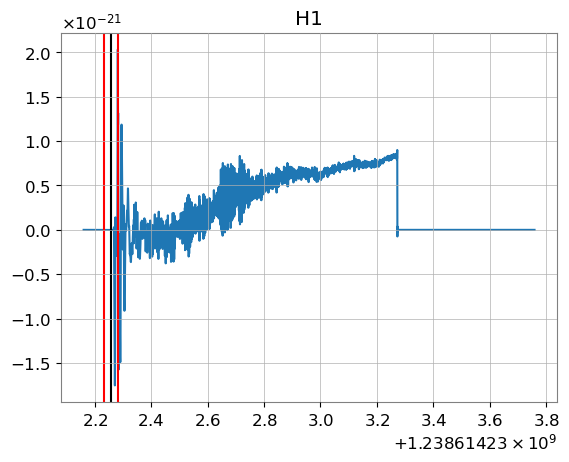

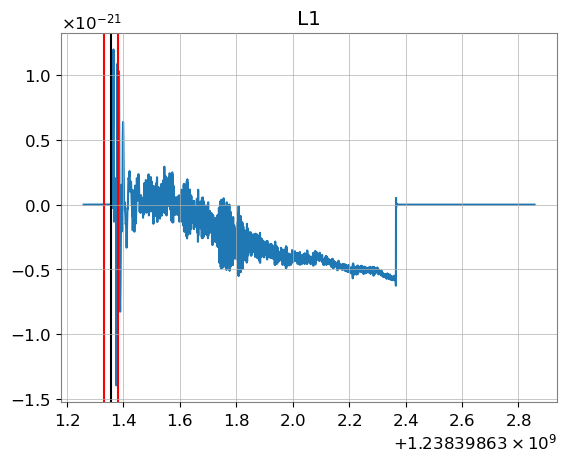

In [17]:
bgid = 10
ifos = ["H1", "L1"]

inject_parameter_list = []
sig_list = []
whitened_inj_list = []
# LFSG, HFSG, BBH, CCSN
waveform = 'ccsn'
if waveform == 'lfsg':
    mode = 'low'
    param_generator = sg_params
    waveform_generator = sg_waveform
elif waveform == 'hfsg':
    mode = 'high'
    param_generator = sg_params
    waveform_generator = sg_waveform
elif waveform == 'bbh':
    mode = None
    param_generator = bbh_params
    waveform_generator = bbh_waveform
elif waveform == 'ccsn':
    mode = None
    param_generator = ccsn_params
    waveform_generator = ccsn_waveform

if waveform == 'ccsn':
    # simulation = "Andresen_2016/s20"
    # simulation = "OConnor_2018/mesa20_pert_LR"
    simulation = "Powell_2020/m39"
    # simulation = "Radice_2019/s20"
    # simulation = "Pan_2021/NR"
    # simulation = "Andresen_2019/s15nr"
    inject_parameters = param_generator(mode, simulation=simulation)
else:
    inject_parameters = param_generator(mode)
snr_low, snr_high = 100, 200
target_snr = np.random.uniform(snr_low, snr_high)
inject_parameters[f'network_snr'] = target_snr
print(f"target_snr: {target_snr}")
signal_ts = dict()
asd = dict()
bg_ts = dict()
inj_ts = dict()
whitened_inj_ts = dict()
for i in range(len(bgsegs[ifo][5:6])):
    for ifo in ifos[:]:
        t0 = bgsegs[ifo][i]
        bg_ts[ifo] = get_bg_ts(ifo, t0)
        signal_ts[ifo] = waveform_generator(ifo, inject_parameters, bg_ts[ifo].t0.value)
        asd[ifo] = select_asd(t0, asd_list[ifo])
        inject_parameters[f't0_{ifo}'] = t0 

    # Rescale SNR
    re_sigs, re_snrs = rescale_snr(target_snr, signal_ts, asd)
    # Injecting
    for ifo in ifos:
        inject_parameters[f'snr_{ifo}'] = re_snrs[ifo]
        inj_ts[ifo] = bg_ts[ifo].inject(re_sigs[ifo])
        whitened_inj_ts[ifo] = process(inj_ts[ifo], asd[ifo]).to_value()
        signal_ts[ifo] = re_sigs[ifo].resample(4096).crop(signal_ts[ifo].t0.value + 1, signal_ts[ifo].t0.value + signal_ts[ifo].duration.value - 1).to_value()

    print(len(signal_ts['H1']), len(whitened_inj_ts['H1']), len(signal_ts['H1']), len(whitened_inj_ts['H1']))
    if len(signal_ts['H1']) == len(whitened_inj_ts['H1']) and len(whitened_inj_ts['H1']) == 6*4096 and len(signal_ts['L1']) == len(whitened_inj_ts['L1']) and len(whitened_inj_ts['L1']) == 6*4096:
        inject_parameter_list.append(inject_parameters)
        sig_list.append(signal_ts)
        whitened_inj_list.append(whitened_inj_ts)
    print(f'{len(inject_parameter_list)} injection produced.')
    print(inject_parameter_list)
    # print(sig_list)
    # print(whitened_inj_list)
    for ifo in ifos:
        t0 = inject_parameter_list[0][f't0_{ifo}']
        times = np.linspace(t0, t0+6, 4096*6)
        st, ed = int(3*4096) - 400, int(4.5*4096)
        lt = int(3*4096)
        lst = lt - 100
        led = lt + 100

        # plt.figure()
        # plt.plot(times[st:ed], whitened_inj_list[0][ifo][st:ed])
        # plt.title(f"{ifo}")
        # plt.axvline(times[lt], color='black')
        # plt.axvline(times[lst], color='red')
        # plt.axvline(times[led], color='red')
        # plt.show()

        plt.figure()
        plt.plot(times[st:ed], sig_list[0][ifo][st:ed])
        plt.title(f"{ifo}")
        plt.axvline(times[lt], color='black')
        plt.axvline(times[lst], color='red')
        plt.axvline(times[led], color='red')
        plt.show()

In [26]:
ifos = ["H1", "L1"]
idstart, idend = 10, 25
bgseg_t_list = dict.fromkeys(ifos)
asd_list = dict.fromkeys(ifos)
for ifo in ifos:
    bgseg_t_list_fname = f'/home/chiajui.chou/GW-anomaly-detection/makedata/{ifo}_bgseg_t_list.hdf5'
    with h5.File(bgseg_t_list_fname, 'r') as f:
        bgseg_t_list[ifo] = f['bgseg_t_list'][idstart:idend]
        print(f"Number of time in bgseg_t_list, {ifo}: {len(bgseg_t_list[ifo])}")

    asd_folder = f"/home/chiajui.chou/GW-anomaly-detection/data/asds/{ifo}/O3"
    asd_list[ifo] = glob.glob(f"{asd_folder}/*.txt")
    asd_list[ifo] = sorted(asd_list[ifo])

Number of time in bgseg_t_list, H1: 15
Number of time in bgseg_t_list, L1: 15


### LFSG, HFSG

In [643]:
ifos = ["H1", "L1"]
duration = 8
sampling_frequency = 16384
mode = 'low'

inject_parameter_list = []
sig_list = []
whitened_inj_list = []
for i in range(idstart, idstart+2):
    # Injection using pycbc
    inject_parameters = sg_params(mode)
    asd = dict()
    snr = dict()
    signal_ts = dict()
    inj_ts = dict()
    whitened_inj_ts = dict()
    for ifo in ifos:
        t0 = bgseg_t_list[ifo][i]
        bg_ts = get_bg_ts(ifo, t0)
        signal_ts[ifo] = sg_waveform(ifo, inject_parameters, bg_ts.t0.value)
        # Estimate SNR
        asd[ifo] = select_asd(t0, asd_list[ifo])
        snr[ifo] = estimate_snr(signal_ts[ifo], asd[ifo])
        inject_parameters[f'snr_{ifo}'] = snr[ifo]
        inject_parameters[f't0_{ifo}'] = t0 
        # Inject signal and process the injected timeseries
        inj_ts[ifo] = bg_ts.inject(signal_ts[ifo])
        whitened_inj_ts[ifo] = process(inj_ts[ifo], asd[ifo]).to_value()
        signal_ts[ifo] = signal_ts[ifo].resample(4096).crop(signal_ts[ifo].t0.value + 1, signal_ts[ifo].t0.value + signal_ts[ifo].duration.value - 1).to_value()

    inject_parameter_list.append(inject_parameters)
    sig_list.append(signal_ts)
    whitened_inj_list.append(whitened_inj_ts)

with h5.File('/home/chiajui.chou/GW-anomaly-detection/makedata/inj_params_lfsg-test.hdf5', 'w') as w:
    names = list(inject_parameter_list[0].keys())
    dt = np.dtype({'names': names, 'formats': ['f16']*len(inject_parameter_list[0])})
    data = np.array([tuple(inject_parameter.values()) for inject_parameter in inject_parameter_list], dtype=dt)
    w.create_dataset(
        'inject_parameters',
        shape=data.shape,
        dtype=dt,
        data=data,
    )

    for ifo in ifos:
        data = np.stack([ts[ifo] for ts in whitened_inj_list])
        w.create_dataset(
            ifo,
            shape=data.shape,
            dtype=data.dtype,
            data=data
        )
        data = np.stack([ts[ifo] for ts in sig_list])
        w.create_dataset(
            f'sg_{ifo}',
            shape=data.shape,
            dtype=data.dtype,
            data=data
        )

<KeysViewHDF5 ['H1', 'L1', 'bbh_H1', 'bbh_L1', 'inject_parameters']>
(88,)
('Mc', 'q', 'a1', 'a2', 'tilt1', 'tilt2', 'phi12', 'phijl', 'thetajn', 'distance', 'phase', 'ra', 'dec', 'psi', 'mass1', 'mass2', 'f_ref', 'inclination', 'spin1x', 'spin1y', 'spin1z', 'spin2x', 'spin2y', 'spin2z', 'approximant', 'snr_H1', 't0_H1', 'snr_L1', 't0_L1')
(88, 24576)
(88, 24576)
47.64595523469570537 43.38824144919446013


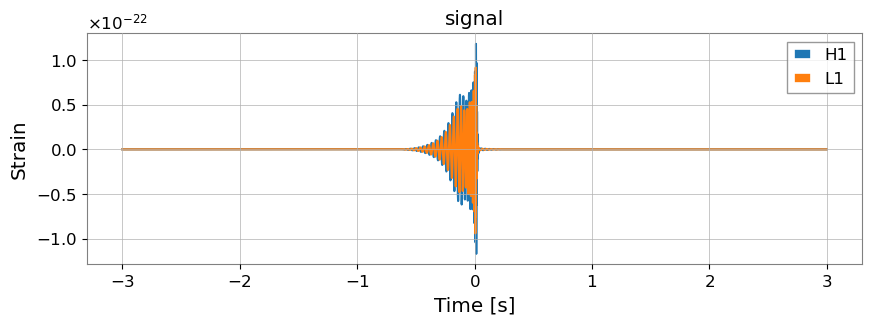

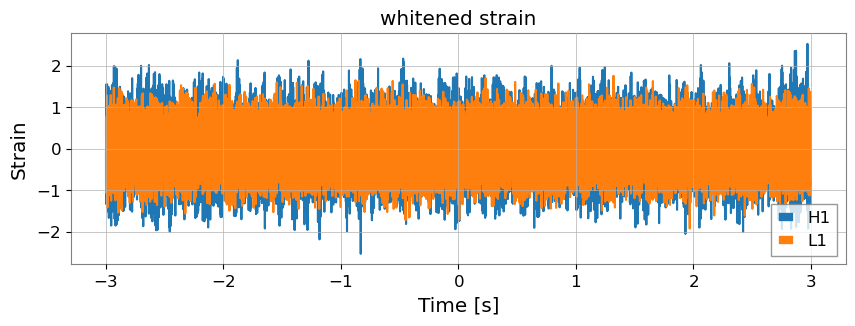

In [705]:
# waveform = 'lfsg'
# waveform = 'hfsg'
waveform = 'bbh'
idstart, idend = 100,200
# with h5.File('/home/chiajui.chou/GW-anomaly-detection/makedata/inj_params_lfsg-test.hdf5', 'r') as f:
with h5.File(f'/home/chiajui.chou/GW-anomaly-detection/data/inj_ts/O3/{waveform}/inj_{waveform}-{idstart}-{idend}.hdf5', 'r') as f:
    print(f.keys())
    print(f['inject_parameters'].shape)
    print(f['inject_parameters'][id].dtype.names)
    for id in range(-1, 0):
        print(f[ifo].shape)
        print(f[f'{waveform}_{ifo}'].shape)
        print(f['inject_parameters'][id]['snr_H1'], f['inject_parameters'][id]['snr_L1'])
        plt.figure(figsize=(10, 3))
        for ifo in ifos:
            plt.plot(np.arange(-3, 3, 1/4096), f[f'{waveform}_{ifo}'][id], label=ifo)
        plt.title('signal')
        plt.xlabel('Time [s]')
        plt.ylabel('Strain')
        plt.legend()
        plt.show()
        plt.figure(figsize=(10, 3))
        for ifo in ifos:
            plt.plot(np.arange(-3, 3, 1/4096), f[ifo][id], label=ifo)
        plt.title('whitened strain')
        plt.xlabel('Time [s]')
        plt.ylabel('Strain')
        plt.legend()
        plt.show()

### BBH

In [662]:
ifos = ['H1', 'L1']
duration = 8
sampling_frequency = 16384

inject_parameter_list = []
sig_list = []
whitened_inj_list = []
for i in range(idstart, idstart+2):
    # Injection using pycbc
    inject_parameters = bbh_params(None)
    print(inject_parameters)
    asd = dict()
    snr = dict()
    signal_ts = dict()
    inj_ts = dict()
    whitened_inj_ts = dict()
    for ifo in ifos:
        t0 = bgseg_t_list[ifo][i]
        bg_ts = get_bg_ts(ifo, t0)
        signal_ts[ifo] = bbh_waveform(ifo, inject_parameters, bg_ts.t0.value)
        # Estimate SNR
        asd[ifo] = select_asd(t0, asd_list[ifo])
        snr[ifo] = estimate_snr(signal_ts[ifo], asd[ifo])
        inject_parameters[f'snr_{ifo}'] = snr[ifo]
        inject_parameters[f't0_{ifo}'] = t0 
        # Inject signal and process the injected timeseries
        inj_ts[ifo] = bg_ts.inject(signal_ts[ifo])
        whitened_inj_ts[ifo] = process(inj_ts[ifo], asd[ifo]).to_value()
        signal_ts[ifo] = signal_ts[ifo].resample(4096).crop(signal_ts[ifo].t0.value + 1, signal_ts[ifo].t0.value + signal_ts[ifo].duration.value - 1).to_value()

    inject_parameter_list.append(inject_parameters)
    sig_list.append(signal_ts)
    whitened_inj_list.append(whitened_inj_ts)

with h5.File('/home/chiajui.chou/GW-anomaly-detection/makedata/inj_params_bbh-test.hdf5', 'w') as w:
    names = list(inject_parameter_list[0].keys())
    dt = np.dtype({'names': names, 'formats': ['f16']*(len(inject_parameter_list[0]) - 5) + [h5.string_dtype(encoding='ascii')] + ['f16']*4})
    data = np.array([tuple(inject_parameter.values()) for inject_parameter in inject_parameter_list], dtype=dt)
    w.create_dataset(
        'inject_parameters',
        shape=data.shape,
        dtype=dt,
        data=data,
    )
    for ifo in ifos:
        data = np.stack([ts[ifo] for ts in whitened_inj_list])
        w.create_dataset(
            ifo,
            shape=data.shape,
            dtype=data.dtype,
            data=data
        )
        data = np.stack([ts[ifo] for ts in sig_list])
        w.create_dataset(
            f'bbh_{ifo}',
            shape=data.shape,
            dtype=data.dtype,
            data=data
        )


{'Mc': 37.126814336570355, 'q': 0.946742326431371, 'a1': 0.91352931196702, 'a2': 0.8102749774783768, 'tilt1': 0.18212324461281654, 'tilt2': 0.8300945903685842, 'phi12': 0.5110281935709897, 'phijl': 3.648402166638016, 'thetajn': 1.217085194506, 'distance': 4071.355227006205, 'phase': 4.364716595292372, 'ra': 2.2892604830866565, 'dec': 0.11853106594490881, 'psi': 0.22464590134133874, 'mass1': 43.83391935322613, 'mass2': 41.4994267850784, 'f_ref': 10, 'inclination': 1.2766047189231815, 'spin1x': -0.07880507763063566, 'spin1y': 0.1454842941689278, 'spin1z': 0.8984207720844032, 'spin2x': -0.5055771921352286, 'spin2y': 0.319328427079525, 'spin2z': 0.319328427079525, 'approximant': 'IMRPhenomPv2'}
{'Mc': 84.5768190801621, 'q': 0.7922531897584664, 'a1': 0.7875343210563547, 'a2': 0.7822429840274221, 'tilt1': 2.2873742524293736, 'tilt2': 1.5175747909243689, 'phi12': 1.1827311148699127, 'phijl': 6.150126884925512, 'thetajn': 1.4684137311257885, 'distance': 3741.3014592654304, 'phase': 0.057262934

(5,)
139.16449701360008362 148.57983016213836436


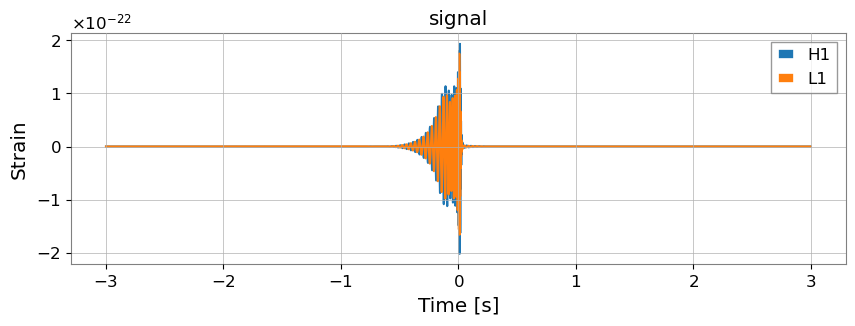

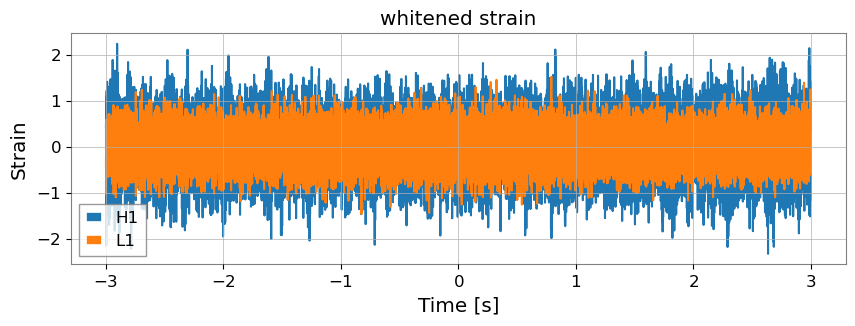

53.44972870995491121 56.148496051851999766


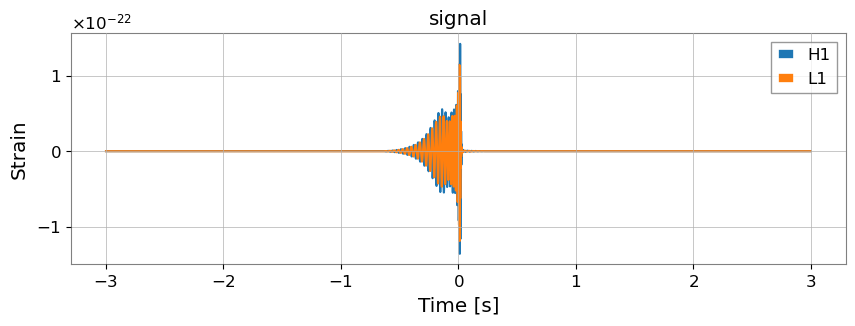

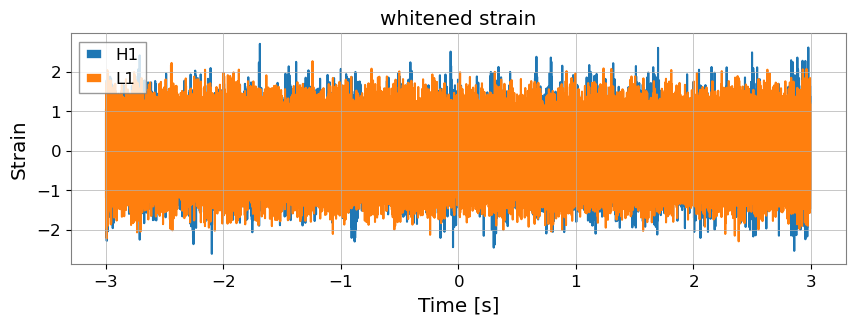

20.344700405740915983 19.781861388968422943


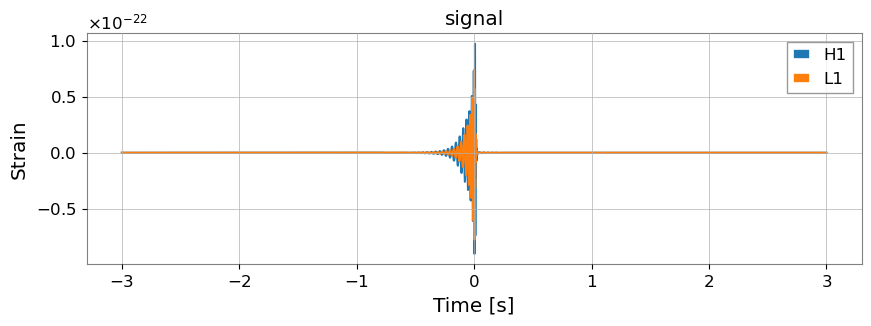

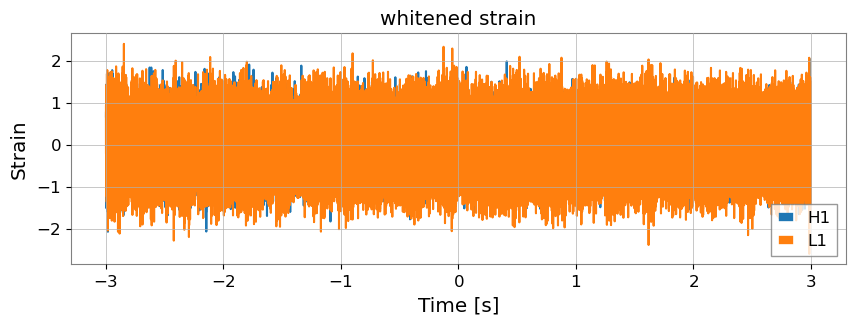

65.29992755544625993 226.84033025820011176


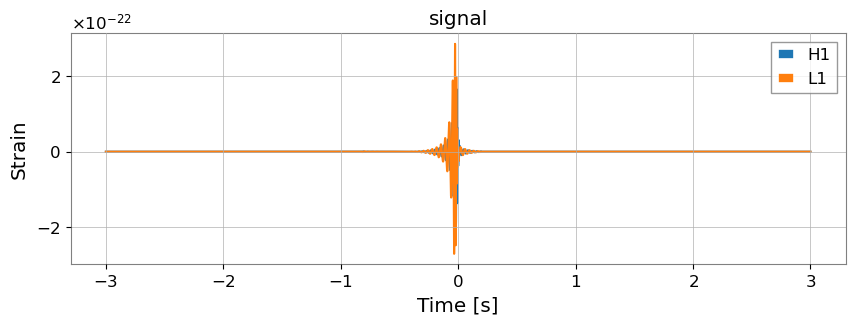

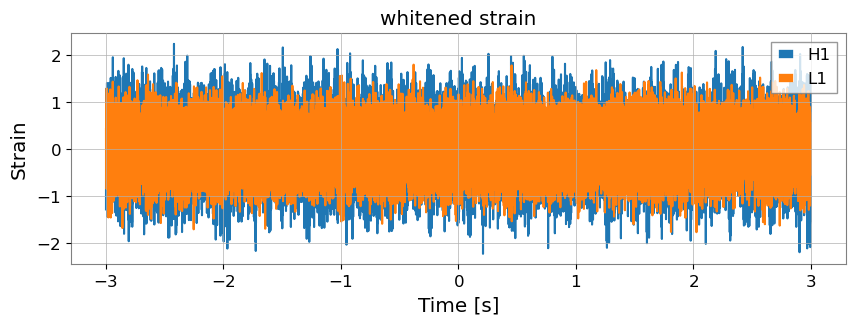

18.736474132194853581 162.59975599815868463


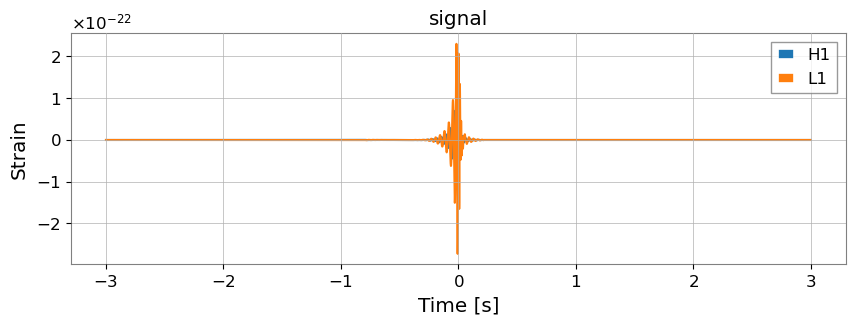

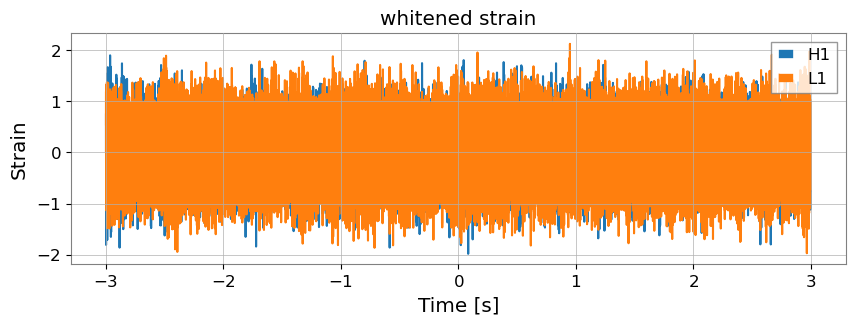

In [670]:
waveform = 'bbh'
# with h5.File('/home/chiajui.chou/GW-anomaly-detection/makedata/inj_params_bbh-test.hdf5', 'r') as f:
with h5.File(f'/home/chiajui.chou/GW-anomaly-detection/data/inj_ts/O3/{waveform}/inj_{waveform}-5-10.hdf5', 'r') as f:
    print(f['inject_parameters'].shape)
    # print(f['inject_parameters'][id].dtype.names)
    # print(f['inject_parameters'][id])
    for id in range(5):
        print(f['inject_parameters'][id]['snr_H1'], f['inject_parameters'][id]['snr_L1'])
        plt.figure(figsize=(10, 3))
        for ifo in ifos:
            plt.plot(np.arange(-3, 3, 1/4096), f[f'{waveform}_{ifo}'][id], label=ifo)
        plt.title('signal')
        plt.xlabel('Time [s]')
        plt.ylabel('Strain')
        plt.legend()
        plt.show()
        plt.figure(figsize=(10, 3))
        for ifo in ifos:
            plt.plot(np.arange(-3, 3, 1/4096), f[ifo][id], label=ifo)
        plt.title('whitened strain')
        plt.xlabel('Time [s]')
        plt.ylabel('Strain')
        plt.legend()
        plt.show()